In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler # onehot encoding и стандартизации
from sklearn.model_selection import cross_val_score

%config InlineBackend.figure_format = 'retina'
sns.set_palette('gist_earth')

import warnings
warnings.filterwarnings("ignore")

In [ ]:
PATH_TO_ENGINEERED_DATA = "data/aggregated/20250624/engineered_features.csv"
PATH_TO_FIGHTERS_DATA = "data/processed/20250623/cleaned_fighters.csv"

In [3]:
data = pd.read_csv("./" + PATH_TO_ENGINEERED_DATA)
fighters_data = pd.read_csv("./" + PATH_TO_FIGHTERS_DATA)

In [4]:
data = data.sort_values('event_date')

In [5]:
# subsetting only data that is known at the time of each fight (and 'result' as a target variable)

data_model = data[[
        'event_date',
        'result',
        'weight_class',
        'belt',
        'height_fighter',
        'reach_fighter',
        'stance_fighter',
        'sex_fighter',
        'country_fighter',
        'stance_opp',
        'country_opp',
        'age_fighter',
        'cum_total_fights_fighter',
        'cum_wins_fighter',
        'cum_losses_fighter',
        'perc_fights_won_fighter',
        'perc_fights_lost_fighter',
        'method_DQ_wins_fighter',
        'method_DQ_losses_fighter',
        'method_KO_TKO_wins_fighter',
        'method_KO_TKO_losses_fighter',
        'method_M_DEC_wins_fighter',
        'method_M_DEC_losses_fighter',
        'method_SUB_wins_fighter',
        'method_SUB_losses_fighter',
        'method_S_DEC_wins_fighter',
        'method_S_DEC_losses_fighter',
        'method_U_DEC_wins_fighter',
        'method_U_DEC_losses_fighter',
        'winning_streak_fighter',
        'losing_streak_fighter',
        'prev_result_fighter',
        'kd_fighter_mean',
        'str_fighter_mean',
        'str_total_fighter_mean',
        'td_fighter_mean',
        'td_total_fighter_mean',
        'sub_fighter_mean',
        'revs_fighter_mean',
        'time_control_perc_fighter_mean',
        'slpm_fighter_mean',
        'str_acc_fighter_mean',
        'sapm_fighter_mean',
        'str_def_fighter_mean',
        'td_avg_fighter_mean',
        'td_acc_fighter_mean',
        'td_def_fighter_mean',
        'sub_avg_fighter_mean',
        'mean_rounds_fighter',
        'belt_cum_if_won_fighter',
        'perf_cum_if_won_fighter',
        'fight_cum_if_won_fighter',
        'ko_cum_if_won_fighter',
        'sub_cum_if_won_fighter',
        'cum_total_fights_opp',
        'cum_wins_opp',
        'cum_losses_opp',
        'perc_fights_won_opp',
        'perc_fights_lost_opp',
        'method_DQ_wins_opp',
        'method_DQ_losses_opp',
        'method_KO_TKO_wins_opp',
        'method_KO_TKO_losses_opp',
        'method_M_DEC_wins_opp',
        'method_M_DEC_losses_opp',
        'method_SUB_wins_opp',
        'method_SUB_losses_opp',
        'method_S_DEC_wins_opp',
        'method_S_DEC_losses_opp',
        'method_U_DEC_wins_opp',
        'method_U_DEC_losses_opp',
        'winning_streak_opp',
        'losing_streak_opp',
        'prev_result_opp',
        'kd_opp_mean',
        'str_opp_mean',
        'str_total_opp_mean',
        'td_opp_mean',
        'td_total_opp_mean',
        'sub_opp_mean',
        'revs_opp_mean',
        'time_control_perc_opp_mean',
        'slpm_opp_mean',
        'str_acc_opp_mean',
        'sapm_opp_mean',
        'str_def_opp_mean',
        'td_avg_opp_mean',
        'td_acc_opp_mean',
        'td_def_opp_mean',
        'sub_avg_opp_mean',
        'mean_rounds_opp',
        'belt_cum_if_won_opp',
        'perf_cum_if_won_opp',
        'fight_cum_if_won_opp',
        'ko_cum_if_won_opp',
        'sub_cum_if_won_opp',
        'age_diff',
        'height_diff',
        'reach_diff',
        'cum_total_fights_diff',
        'cum_wins_diff',
        'cum_losses_diff',
        'perc_fights_won_diff',
        'perc_fights_lost_diff',
        'winning_streak_diff',
        'losing_streak_diff',
        'mean_rounds_diff',
        'belt_cum_if_won_diff',
        'kd_mean_diff',
        'str_mean_diff',
        'str_total_mean_diff',
        'td_mean_diff',
        'td_total_mean_diff',
        'sub_mean_diff',
        'revs_mean_diff',
        'time_control_perc_mean_diff',
        'slpm_mean_diff',
        'str_acc_mean_diff',
        'sapm_mean_diff',
        'str_def_mean_diff',
        'td_avg_mean_diff',
        'td_acc_mean_diff',
        'td_def_mean_diff',
        'sub_avg_mean_diff',
        # 'fighter_odd', # WOP - uncomment if data with odds
        # 'opponent_odd', # WOP - uncomment if data with odds
]].copy()

In [6]:
int64_cols = [
        'result',
        'height_fighter',
        'reach_fighter',
        'sex_fighter',
        'age_fighter',
        'cum_total_fights_fighter',
        'cum_wins_fighter',
        'cum_losses_fighter',
        'method_DQ_wins_fighter',
        'method_DQ_losses_fighter',
        'method_KO_TKO_wins_fighter',
        'method_KO_TKO_losses_fighter',
        'method_M_DEC_wins_fighter',
        'method_M_DEC_losses_fighter',
        'method_SUB_wins_fighter',
        'method_SUB_losses_fighter',
        'method_S_DEC_wins_fighter',
        'method_S_DEC_losses_fighter',
        'method_U_DEC_wins_fighter',
        'method_U_DEC_losses_fighter',
        'winning_streak_fighter',
        'losing_streak_fighter',
        'prev_result_fighter',
        'belt_cum_if_won_fighter',
        'perf_cum_if_won_fighter',
        'fight_cum_if_won_fighter',
        'ko_cum_if_won_fighter',
        'sub_cum_if_won_fighter',
        'cum_total_fights_opp',
        'cum_wins_opp',
        'cum_losses_opp',
        'method_DQ_wins_opp',
        'method_DQ_losses_opp',
        'method_KO_TKO_wins_opp',
        'method_KO_TKO_losses_opp',
        'method_M_DEC_wins_opp',
        'method_M_DEC_losses_opp',
        'method_SUB_wins_opp',
        'method_SUB_losses_opp',
        'method_S_DEC_wins_opp',
        'method_S_DEC_losses_opp',
        'method_U_DEC_wins_opp',
        'method_U_DEC_losses_opp',
        'winning_streak_opp',
        'losing_streak_opp',
        'prev_result_opp',
        'belt_cum_if_won_opp',
        'perf_cum_if_won_opp',
        'fight_cum_if_won_opp',
        'ko_cum_if_won_opp',
        'sub_cum_if_won_opp',
        'age_diff',
        'height_diff',
        'reach_diff',
        'cum_total_fights_diff',
        'cum_wins_diff',
        'cum_losses_diff',
        'winning_streak_diff',
        'losing_streak_diff',
        'belt_cum_if_won_diff'
]

float64_cols = [
        'perc_fights_won_fighter',
        'perc_fights_lost_fighter',
        'kd_fighter_mean',
        'str_fighter_mean',
        'str_total_fighter_mean',
        'td_fighter_mean',
        'td_total_fighter_mean',
        'sub_fighter_mean',
        'revs_fighter_mean',
        'time_control_perc_fighter_mean',
        'slpm_fighter_mean',
        'str_acc_fighter_mean',
        'sapm_fighter_mean',
        'str_def_fighter_mean',
        'td_avg_fighter_mean',
        'td_acc_fighter_mean',
        'td_def_fighter_mean',
        'sub_avg_fighter_mean',
        'mean_rounds_fighter',
        'perc_fights_won_opp',
        'perc_fights_lost_opp',
        'kd_opp_mean',
        'str_opp_mean',
        'str_total_opp_mean',
        'td_opp_mean',
        'td_total_opp_mean',
        'sub_opp_mean',
        'revs_opp_mean',
        'time_control_perc_opp_mean',
        'slpm_opp_mean',
        'str_acc_opp_mean',
        'sapm_opp_mean',
        'str_def_opp_mean',
        'td_avg_opp_mean',
        'td_acc_opp_mean',
        'td_def_opp_mean',
        'sub_avg_opp_mean',
        'mean_rounds_opp',
        'perc_fights_won_diff',
        'perc_fights_lost_diff',
        'mean_rounds_diff',
        'kd_mean_diff',
        'str_mean_diff',
        'str_total_mean_diff',
        'td_mean_diff',
        'td_total_mean_diff',
        'sub_mean_diff',
        'revs_mean_diff',
        'time_control_perc_mean_diff',
        'slpm_mean_diff',
        'str_acc_mean_diff',
        'sapm_mean_diff',
        'str_def_mean_diff',
        'td_avg_mean_diff',
        'td_acc_mean_diff',
        'td_def_mean_diff',
        'sub_avg_mean_diff',
        # 'fighter_odd', # WOP - uncomment if data with odds
        # 'opponent_odd', # WOP - uncomment if data with odds
]

In [7]:
data_model[int64_cols] = data_model[int64_cols].astype('int64')
data_model[float64_cols] = data_model[float64_cols].astype(float)

In [8]:
# selecting male or female fighters - currently not distinguishing

data_model = data_model.drop(columns = ['sex_fighter', 'weight_class', 'event_date'])

In [10]:
# train and test split based on fighters, not the fights itself - better for avoiding hidden dataleaks

names_train, names_test = train_test_split(fighters_data['fighter_name'], test_size=0.10, shuffle = True)

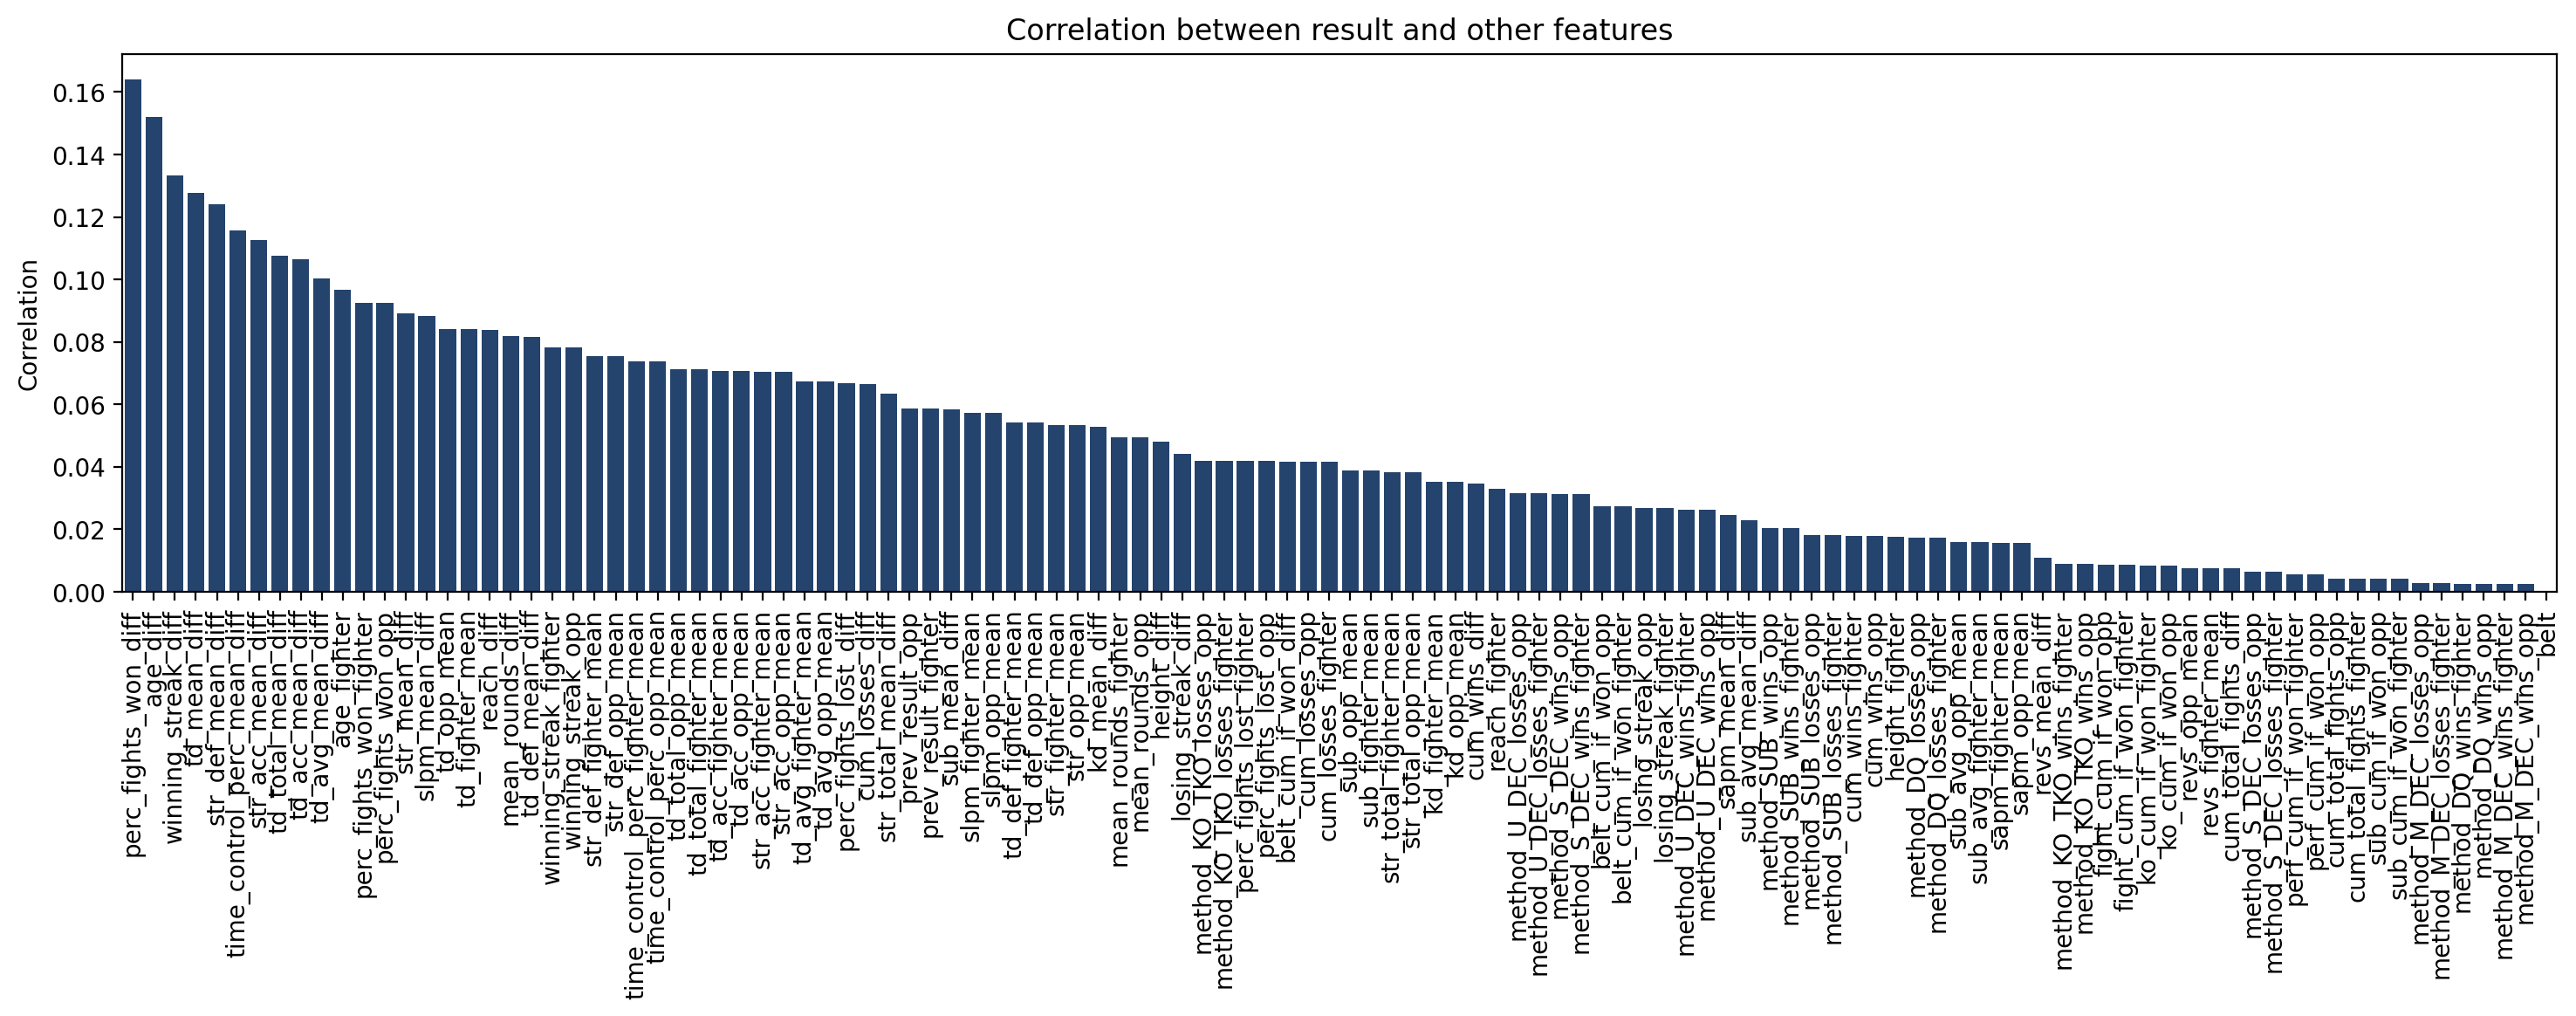

In [12]:
# plotting correlations with 'result'

fig, axes = plt.subplots(figsize=(18, 4));
sns.barplot(data_model.corr(numeric_only=True)['result'].abs().sort_values(ascending = False)[1:]);
axes.tick_params('x', labelrotation=90)
axes.set_title('Correlation between result and other features');
axes.set_ylabel('Correlation');

In [13]:
X = data_model.drop('result', axis = 1)
y = data_model['result']

In [14]:
# train - include all fights where names (fighter AND opp) appear in names_train
# test - include all fights where names (fighter OR opp) appear in names_test

train_index = data.fighter_name.isin(names_train) * data.opp_name.isin(names_train)
test_index = data.fighter_name.isin(names_test) + data.opp_name.isin(names_test)

In [15]:
X_train = X[train_index]
y_train = y[train_index]
X_test = X[test_index]
y_test = y[test_index]

In [17]:
# selecting feature columns, numerical and category columns

feature_cols = [
        'height_fighter',
        'reach_fighter',
        'stance_fighter',
        'country_fighter',
        'stance_opp',
        'country_opp',
        'age_fighter',
        # 'age_diff',
        # 'height_diff',
        # 'reach_diff',
        'cum_total_fights_fighter',
        'cum_wins_fighter',
        'cum_losses_fighter',
        'perc_fights_won_fighter',
        'perc_fights_lost_fighter',
        'method_DQ_wins_fighter',
        'method_DQ_losses_fighter',
        'method_KO_TKO_wins_fighter',
        'method_KO_TKO_losses_fighter',
        'method_M_DEC_wins_fighter',
        'method_M_DEC_losses_fighter',
        'method_SUB_wins_fighter',
        'method_SUB_losses_fighter',
        'method_S_DEC_wins_fighter',
        'method_S_DEC_losses_fighter',
        'method_U_DEC_wins_fighter',
        'method_U_DEC_losses_fighter',
        'winning_streak_fighter',
        'losing_streak_fighter',
        'prev_result_fighter',
        'kd_fighter_mean',
        'str_fighter_mean',
        'str_total_fighter_mean',
        'td_fighter_mean',
        'td_total_fighter_mean',
        'sub_fighter_mean',
        'revs_fighter_mean',
        'time_control_perc_fighter_mean',
        'slpm_fighter_mean',
        'str_acc_fighter_mean',
        'sapm_fighter_mean',
        'str_def_fighter_mean',
        'td_avg_fighter_mean',
        'td_acc_fighter_mean',
        'td_def_fighter_mean',
        'sub_avg_fighter_mean',
        'mean_rounds_fighter',
        'belt_cum_if_won_fighter',
        'perf_cum_if_won_fighter',
        'fight_cum_if_won_fighter',
        'ko_cum_if_won_fighter',
        'sub_cum_if_won_fighter',
        'cum_total_fights_opp',
        'cum_wins_opp',
        'cum_losses_opp',
        'perc_fights_won_opp',
        'perc_fights_lost_opp',
        'method_DQ_wins_opp',
        'method_DQ_losses_opp',
        'method_KO_TKO_wins_opp',
        'method_KO_TKO_losses_opp',
        'method_M_DEC_wins_opp',
        'method_M_DEC_losses_opp',
        'method_SUB_wins_opp',
        'method_SUB_losses_opp',
        'method_S_DEC_wins_opp',
        'method_S_DEC_losses_opp',
        'method_U_DEC_wins_opp',
        'method_U_DEC_losses_opp',
        'winning_streak_opp',
        'losing_streak_opp',
        'prev_result_opp',
        'kd_opp_mean',
        'str_opp_mean',
        'str_total_opp_mean',
        'td_opp_mean',
        'td_total_opp_mean',
        'sub_opp_mean',
        'revs_opp_mean',
        'time_control_perc_opp_mean',
        'slpm_opp_mean',
        'str_acc_opp_mean',
        'sapm_opp_mean',
        'str_def_opp_mean',
        'td_avg_opp_mean',
        'td_acc_opp_mean',
        'td_def_opp_mean',
        'sub_avg_opp_mean',
        'mean_rounds_opp',
        'belt_cum_if_won_opp',
        'perf_cum_if_won_opp',
        'fight_cum_if_won_opp',
        'ko_cum_if_won_opp',
        'sub_cum_if_won_opp',
        'age_diff',
        'height_diff',
        'reach_diff',
        'cum_total_fights_diff',
        'cum_wins_diff',
        'cum_losses_diff',
        'perc_fights_won_diff',
        'perc_fights_lost_diff',
        'winning_streak_diff',
        'losing_streak_diff',
        'mean_rounds_diff',
        'belt_cum_if_won_diff',
        'kd_mean_diff',
        'str_mean_diff',
        'str_total_mean_diff',
        'td_mean_diff',
        'td_total_mean_diff',
        'sub_mean_diff',
        'revs_mean_diff',
        'time_control_perc_mean_diff',
        'slpm_mean_diff',
        'str_acc_mean_diff',
        'sapm_mean_diff',
        'str_def_mean_diff',
        'td_avg_mean_diff',
        'td_acc_mean_diff',
        'td_def_mean_diff',
        'sub_avg_mean_diff',
        # 'fighter_odd',
        # 'opponent_odd',
]

cat_cols = [
        'stance_fighter',
        'country_fighter',
        'stance_opp',
        'country_opp'
]

num_cols = [item for item in feature_cols if item not in cat_cols]

In [18]:
# creating pool datasets for catboost

from catboost import CatBoostClassifier, Pool, cv
from sklearn.metrics import accuracy_score

# full dataset for cross validation
dataset = Pool(data=X[feature_cols],
                     label=y,
                     cat_features=cat_cols,
                    )

train_dataset = Pool(data=X_train[feature_cols],
                     label=y_train,
                     cat_features=cat_cols,
                    )

test_dataset = Pool(data=X_test[feature_cols],
                     # label=y_test,
                     cat_features=cat_cols)

In [19]:
%%time

# running catboost 'out of the box'

params = {
'loss_function' : 'Logloss',
'verbose' : True,
'eval_metric': 'Accuracy',
}

model = CatBoostClassifier(**params) 

model.fit(train_dataset) 

train_y_pred = model.predict(train_dataset)
test_y_pred = model.predict(test_dataset)
test_y_pred_proba = model.predict_proba(test_dataset)[:,1]

Learning rate set to 0.031004
0:	learn: 0.5868939	total: 224ms	remaining: 3m 43s
1:	learn: 0.6006061	total: 288ms	remaining: 2m 23s
2:	learn: 0.6027273	total: 329ms	remaining: 1m 49s
3:	learn: 0.6026515	total: 387ms	remaining: 1m 36s
4:	learn: 0.6059848	total: 446ms	remaining: 1m 28s
5:	learn: 0.6049242	total: 503ms	remaining: 1m 23s
6:	learn: 0.6056818	total: 561ms	remaining: 1m 19s
7:	learn: 0.6095455	total: 616ms	remaining: 1m 16s
8:	learn: 0.6099242	total: 670ms	remaining: 1m 13s
9:	learn: 0.6090909	total: 725ms	remaining: 1m 11s
10:	learn: 0.6094697	total: 780ms	remaining: 1m 10s
11:	learn: 0.6107576	total: 835ms	remaining: 1m 8s
12:	learn: 0.6109091	total: 890ms	remaining: 1m 7s
13:	learn: 0.6121970	total: 946ms	remaining: 1m 6s
14:	learn: 0.6137879	total: 1s	remaining: 1m 5s
15:	learn: 0.6168939	total: 1.06s	remaining: 1m 5s
16:	learn: 0.6162121	total: 1.12s	remaining: 1m 4s
17:	learn: 0.6198485	total: 1.17s	remaining: 1m 3s
18:	learn: 0.6209091	total: 1.23s	remaining: 1m 3s
19:

In [20]:
# roc-auc score

from sklearn.metrics import roc_curve, roc_auc_score

test_auc = roc_auc_score(y_test.tolist(), test_y_pred_proba)
print(f'ROC-AUC test: {test_auc:.5f}')

ROC-AUC test: 0.67417


In [21]:
# accuracies scores on train and test

accuracy_train = accuracy_score(y_train, train_y_pred)
accuracy_test = accuracy_score(y_test.tolist(), test_y_pred)
print(f'Accuracy train: {accuracy_train:.5f}')
print(f'Accuracy test: {accuracy_test:.5f}')

Accuracy train: 0.81970
Accuracy test: 0.62730


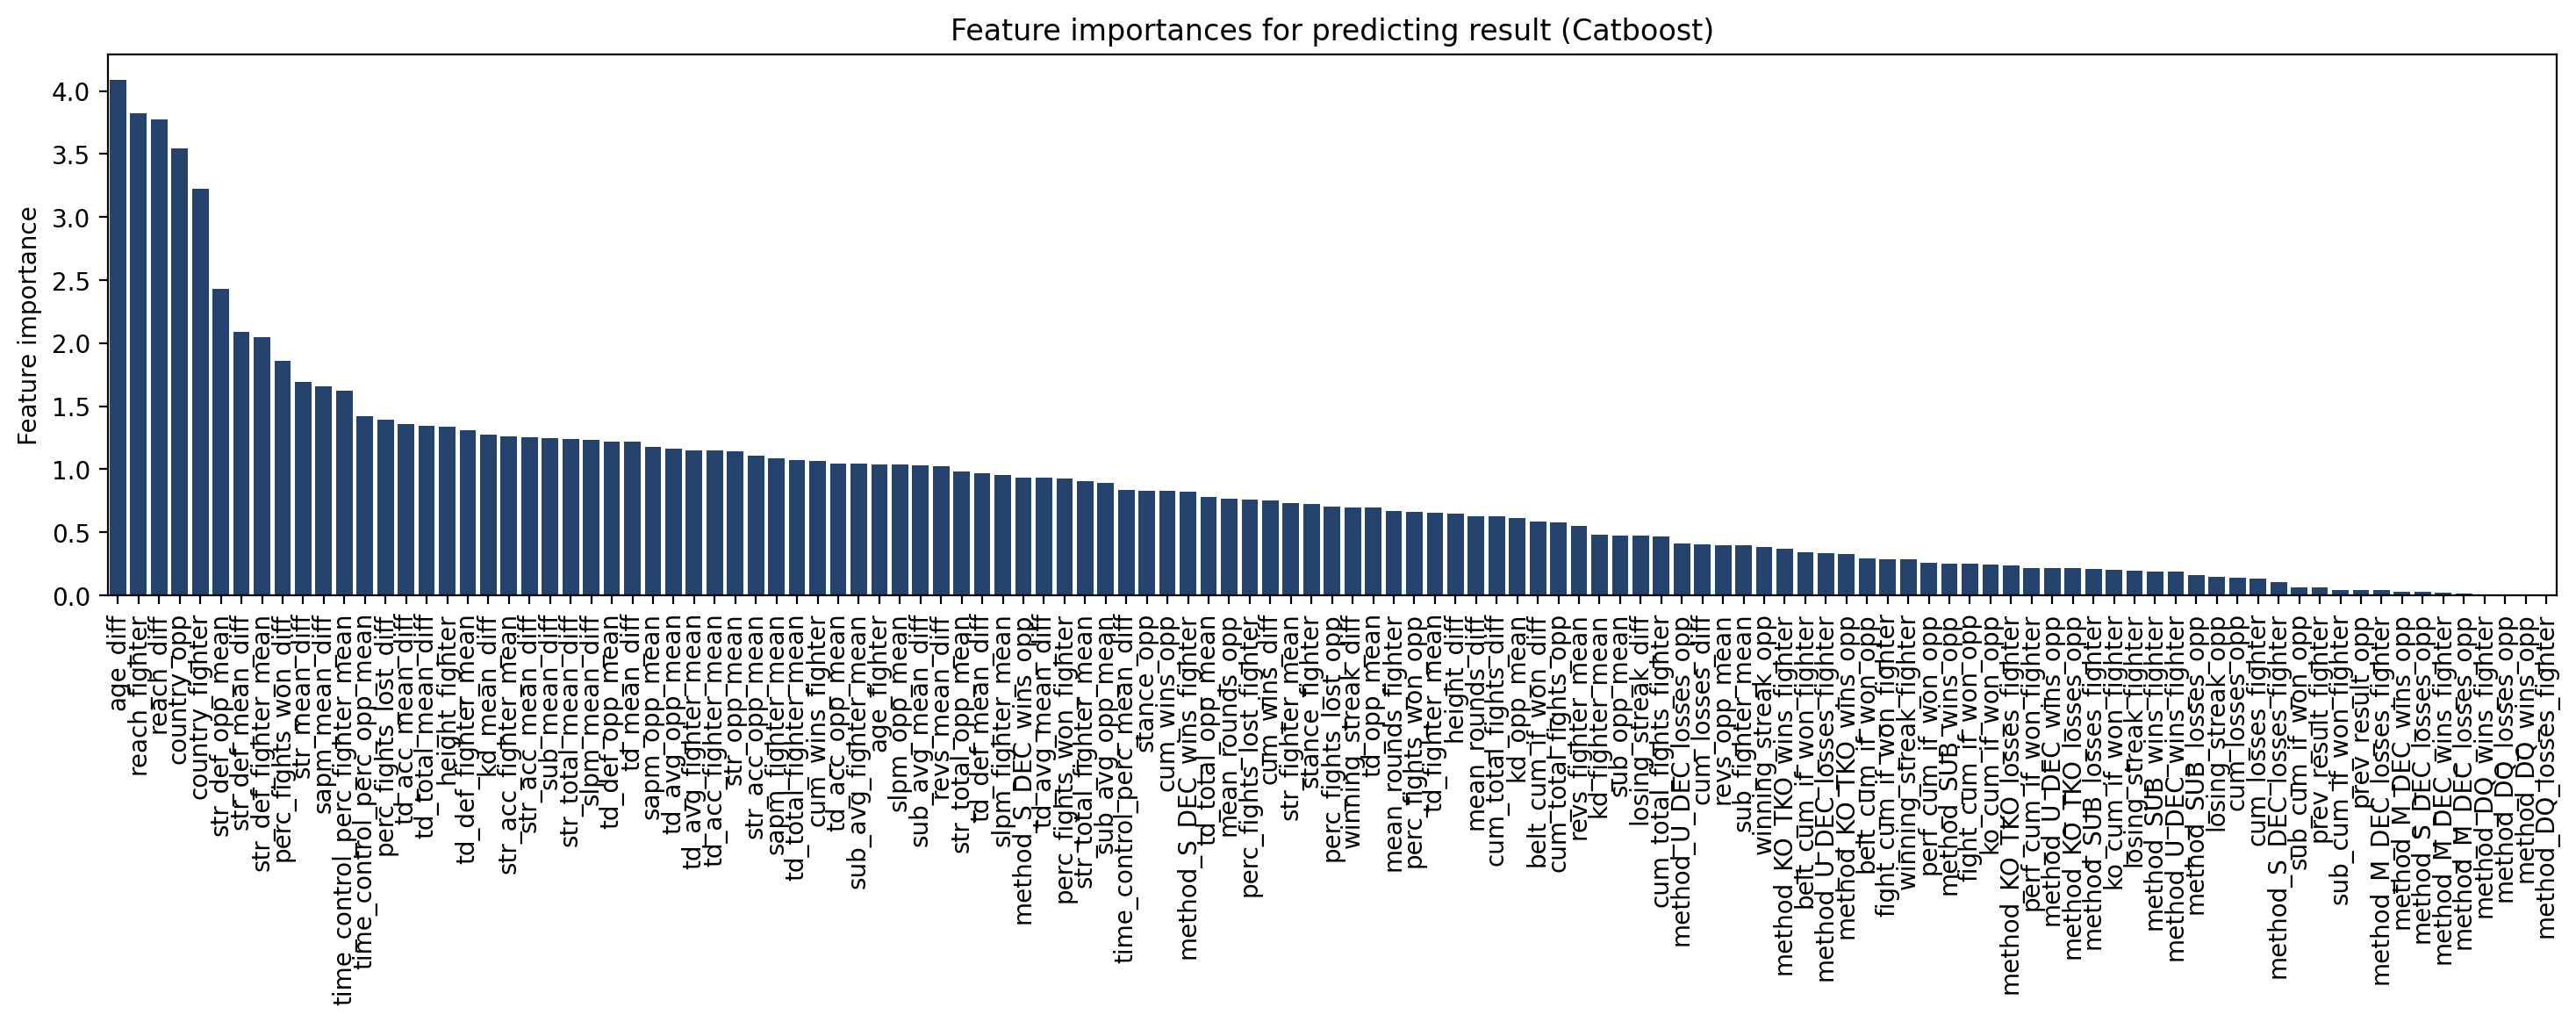

In [22]:
# plotting feature importances

fig, axes = plt.subplots(figsize=(18, 4));
sns.barplot(pd.DataFrame({'FI': model.feature_importances_}, index = train_dataset.get_feature_names()).sort_values('FI', ascending = False)['FI']);
axes.tick_params('x', labelrotation=90)
axes.set_title('Feature importances for predicting result (Catboost)');
axes.set_ylabel('Feature importance');

In [23]:
df1 = data_model[test_index]
df1.reset_index(drop=True, inplace=True)
df2 = pd.DataFrame(test_y_pred)
df2.reset_index(drop=True, inplace=True)
# df3 = y_test
# df3.reset_index(drop=True, inplace=True)

# pd.concat([df1, df2, df3], axis = 1)
pd.concat([df1, df2], axis = 1)

,result,belt,height_fighter,reach_fighter,stance_fighter,country_fighter,stance_opp,country_opp,age_fighter,cum_total_fights_fighter,...,time_control_perc_mean_diff,slpm_mean_diff,str_acc_mean_diff,sapm_mean_diff,str_def_mean_diff,td_avg_mean_diff,td_acc_mean_diff,td_def_mean_diff,sub_avg_mean_diff,0
0,0,0,190,183,Orthodox,Not_Found,Orthodox,Not_Found,30,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,0,0,170,183,Orthodox,Japan,Southpaw,Brazil,30,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.432836,0
2,1,0,185,183,Southpaw,Brazil,Orthodox,Japan,27,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.432836,1
3,1,0,180,183,Orthodox,Not_Found,Orthodox,Not_Found,30,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,1,1,177,183,Orthodox,United_States,Orthodox,Not_Found,30,0,...,0.000000,-11.739130,-0.750000,-1.304348,-0.250000,0.000000,0.000000,-0.500000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,1,0,165,165,Orthodox,United_States,Southpaw,United_States,32,17,...,-0.132580,0.328236,-0.014512,2.169011,0.005775,-1.096703,0.084713,0.182003,0.307656,0
2926,0,0,190,190,Orthodox,Chile,Switch,Azerbaijan,27,8,...,0.015691,2.769412,-0.081989,1.586280,0.103570,-0.400000,-0.250000,-0.293750,1.076462,1
2927,1,0,172,180,Switch,Azerbaijan,Orthodox,Chile,32,10,...,-0.015691,-2.769412,0.081989,-1.586280,-0.103570,0.400000,0.250000,0.293750,-1.076462,0
2928,1,0,170,178,Southpaw,Russia,Southpaw,Not_Found,33,6,...,0.438154,0.107900,0.245198,-3.591739,-0.085460,2.009345,0.341991,0.152778,2.305805,1


### Performing Time Series cross-valiation with Catboost

In [24]:
%%time

# performing Time Series cross-valiation with Catboost

params = {
    'iterations': 1000,       # Number of boosting iterations
    'loss_function': 'Logloss',  # For multi-class classification
    'eval_metric': 'Accuracy',       # Evaluation metric
    'verbose': True
}

cv_results = cv(
    params=params,
    pool=dataset,
    fold_count=5,               # Number of folds (e.g., 5-fold CV)
    type = 'TimeSeries', 
    # partition_random_seed=42,   # Seed for reproducibility
    # shuffle=True,               # Shuffle data before cross-validation
    # stratified=True,            # Stratify folds by class label
    verbose=False               # Set to True to see progress
)

# Display the CV results
cv_results

Training on fold [0/5]

bestTest = 0.6154704351
bestIteration = 450

Training on fold [1/5]

bestTest = 0.6253720238
bestIteration = 304

Training on fold [2/5]

bestTest = 0.6082589286
bestIteration = 246

Training on fold [3/5]

bestTest = 0.6272321429
bestIteration = 122

Training on fold [4/5]

bestTest = 0.6365327381
bestIteration = 411

CPU times: total: 34min 53s
Wall time: 4min


,iterations,test-Accuracy-mean,test-Accuracy-std,train-Accuracy-mean,train-Accuracy-std,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std
0,0,0.558069,0.016194,0.611771,0.026153,0.692117,0.000343,0.690737,0.001200
1,1,0.566550,0.017448,0.621806,0.026890,0.691125,0.000589,0.688874,0.001752
2,2,0.577041,0.022252,0.636560,0.027794,0.690016,0.000739,0.686493,0.002705
3,3,0.578306,0.022343,0.636917,0.028759,0.689101,0.000905,0.684838,0.003128
4,4,0.584109,0.021236,0.639157,0.030358,0.687969,0.001196,0.682838,0.003980
...,...,...,...,...,...,...,...,...,...
995,995,0.608437,0.013611,0.891091,0.058470,0.659589,0.008409,0.389813,0.099955
996,996,0.608289,0.013456,0.891334,0.058648,0.659568,0.008421,0.389679,0.100003
997,997,0.609256,0.013166,0.891454,0.058576,0.659555,0.008375,0.389532,0.100074
998,998,0.609107,0.013284,0.891309,0.058521,0.659547,0.008372,0.389426,0.100099


In [25]:
mean_accuracy = cv_results['test-Accuracy-mean'].max()
print(f'Mean Accuracy: {mean_accuracy:.5f}')

Mean Accuracy: 0.61878


### Performing grid search with time series cross validation

In [26]:
%%time

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder

# need to encode categorical data first to feed it to GridSearchCV

X = data_model.drop('result', axis = 1)
y = data_model['result']

cat_data = X[cat_cols]
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(cat_data)
codes = enc.transform(cat_data).toarray().astype(np.int64)
feature_names = enc.get_feature_names_out(cat_data.columns)
X = pd.concat([X[num_cols],
               pd.DataFrame(codes, columns = feature_names)], axis=1)

model_params = {
'loss_function' : 'Logloss',
'verbose' : True,
'eval_metric': 'Accuracy',
}

# Define the model
model = CatBoostClassifier(**model_params)

# Define the parameter grid
param_grid = {
    'iterations': [50, 100, 1000],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5]
}

# Define the time series cross-validator
tscv = TimeSeriesSplit(n_splits=5)

# Set up GridSearchCV with the TimeSeriesSplit cross-validator
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',  # Adjust scoring based on your needs
    n_jobs=-1                          # Use all available cores
)

# Run the grid search
grid_search.fit(X, y)

0:	learn: 0.5816491	total: 10.1ms	remaining: 10.1s
1:	learn: 0.5862988	total: 20.6ms	remaining: 10.3s
2:	learn: 0.5880967	total: 30.6ms	remaining: 10.2s
3:	learn: 0.5909485	total: 40.2ms	remaining: 10s
4:	learn: 0.5930564	total: 64.8ms	remaining: 12.9s
5:	learn: 0.5958462	total: 75.6ms	remaining: 12.5s
6:	learn: 0.5960322	total: 84.9ms	remaining: 12.1s
7:	learn: 0.5938624	total: 94.5ms	remaining: 11.7s
8:	learn: 0.5949783	total: 105ms	remaining: 11.5s
9:	learn: 0.5958462	total: 114ms	remaining: 11.3s
10:	learn: 0.5955983	total: 124ms	remaining: 11.2s
11:	learn: 0.5952263	total: 134ms	remaining: 11s
12:	learn: 0.5951643	total: 144ms	remaining: 10.9s
13:	learn: 0.5952883	total: 154ms	remaining: 10.8s
14:	learn: 0.5938004	total: 164ms	remaining: 10.8s
15:	learn: 0.5962182	total: 175ms	remaining: 10.7s
16:	learn: 0.5972102	total: 186ms	remaining: 10.7s
17:	learn: 0.5982641	total: 196ms	remaining: 10.7s
18:	learn: 0.5968382	total: 206ms	remaining: 10.6s
19:	learn: 0.5970242	total: 216ms	rem

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=<catboost.core.CatBoostClassifier object at 0x0000016889072ED0>,
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [50, 100, 1000],
                         'l2_leaf_reg': [1, 3, 5],
                         'learning_rate': [0.01, 0.1, 0.2]},
             scoring='accuracy')

In [27]:
# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'depth': 4, 'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
Best score: 0.6078125


### Performing Optuna search with time series cross validation

In [28]:
from sklearn.metrics import accuracy_score
import optuna

In [29]:
%%time

X = data_model.drop('result', axis = 1)
y = data_model['result']

# The objective function is where you define the model and parameter search space for Optuna. Within the function, you’ll:
# Sample hyperparameters with trial.suggest_* methods.
# Use TimeSeriesSplit for cross-validation.
# Train and evaluate the model on each fold, then return the average validation error (e.g., RMSE).

def objective(trial):
    # Define the hyperparameter search space
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 1, 255),
        'loss_function': 'Logloss',
        'eval_metric': 'Accuracy'
    }

    # Set up time series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    for train_index, valid_index in tscv.split(X):
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        # Create Pool for training and validation with categorical feature specification
        train_pool = Pool(data=X_train, label=y_train, cat_features=cat_cols)
        valid_pool = Pool(data=X_valid, label=y_valid, cat_features=cat_cols)

        # Create and train the CatBoost model
        model = CatBoostClassifier(**params, verbose=0)
        model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

        # Predict and calculate accuracy
        preds = model.predict(valid_pool)
        accuracy = accuracy_score(y_valid, preds)
        cv_scores.append(accuracy)

    # Return the mean accuracy across folds
    return np.mean(cv_scores)

# Create the study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # You can set n_trials to control the number of trials

[I 2025-06-24 13:41:56,235] A new study created in memory with name: no-name-71c65d3f-2e42-4125-afb6-9d10139c7db0
[I 2025-06-24 13:42:33,377] Trial 0 finished with value: 0.5953125 and parameters: {'iterations': 281, 'depth': 9, 'learning_rate': 0.10418862850803398, 'l2_leaf_reg': 0.07177150347410327, 'random_strength': 0.36281348185566004, 'bagging_temperature': 0.7014323805216152, 'border_count': 197}. Best is trial 0 with value: 0.5953125.
[I 2025-06-24 13:43:08,656] Trial 1 finished with value: 0.6137648809523809 and parameters: {'iterations': 572, 'depth': 6, 'learning_rate': 0.055710376155013674, 'l2_leaf_reg': 0.08453657645328926, 'random_strength': 9.701654204336884e-05, 'bagging_temperature': 0.4033492171846298, 'border_count': 39}. Best is trial 1 with value: 0.6137648809523809.
[I 2025-06-24 13:43:56,776] Trial 2 finished with value: 0.6092261904761904 and parameters: {'iterations': 368, 'depth': 9, 'learning_rate': 0.028958240248612058, 'l2_leaf_reg': 0.20248814125708323, '

CPU times: total: 3h 18min 53s
Wall time: 32min 31s


In [30]:
print("Best parameters:", study.best_params)
print("Best accuracy:", '%.5f' % study.best_value)

Best parameters: {'iterations': 364, 'depth': 6, 'learning_rate': 0.05802066076770233, 'l2_leaf_reg': 8.060487929363473, 'random_strength': 2.887630978461848, 'bagging_temperature': 0.04909185032967566, 'border_count': 21}
Best accuracy: 0.62493


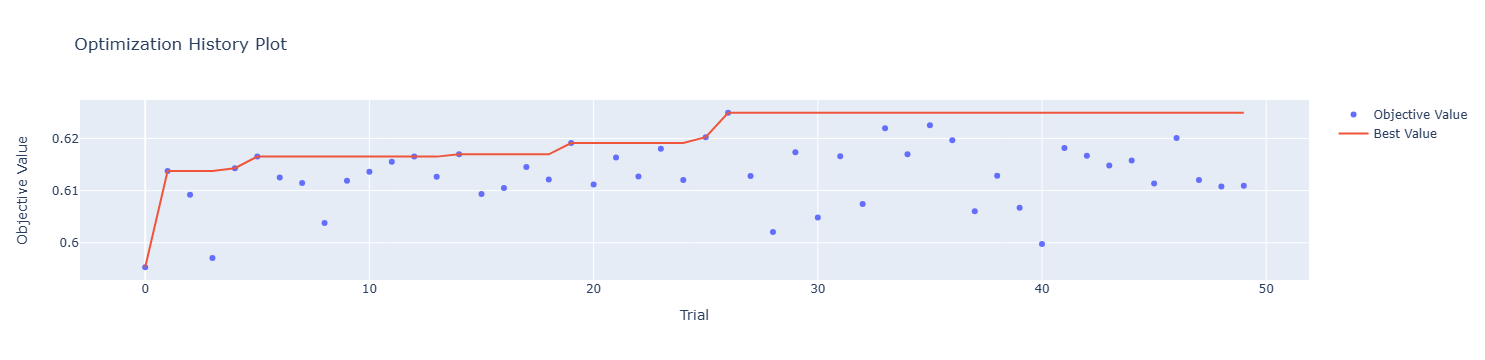

In [31]:
# Import visualization modules
from optuna.visualization import plot_optimization_history, plot_param_importances

# Plot optimization history
plot_optimization_history(study)

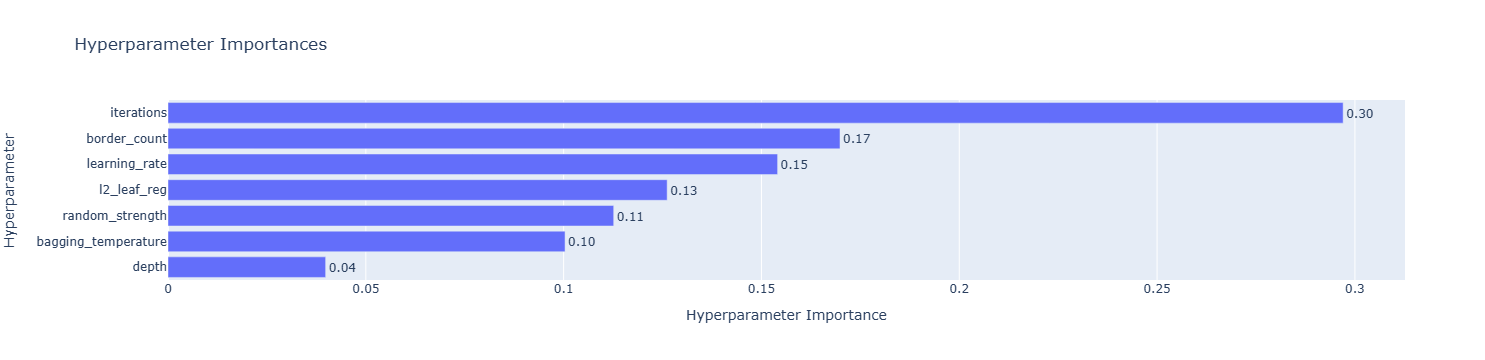

In [32]:
# Plot parameter importances
plot_param_importances(study)

### Apply optimal parameters to train/test

In [33]:
study.best_params

{'iterations': 364,
 'depth': 6,
 'learning_rate': 0.05802066076770233,
 'l2_leaf_reg': 8.060487929363473,
 'random_strength': 2.887630978461848,
 'bagging_temperature': 0.04909185032967566,
 'border_count': 21}

In [34]:
%%time

# running catboost with optimal parameters

params = {
'loss_function' : 'Logloss',
'verbose' : True,
'eval_metric': 'Accuracy',
}

best_params = study.best_params

model = CatBoostClassifier(**params, **best_params) 

model.fit(train_dataset) 

train_y_pred = model.predict(train_dataset)
test_y_pred = model.predict(test_dataset)
test_y_pred_proba = model.predict_proba(test_dataset)[:,1]

0:	learn: 0.5709848	total: 66.8ms	remaining: 24.2s
1:	learn: 0.5919697	total: 127ms	remaining: 23.1s
2:	learn: 0.5859091	total: 188ms	remaining: 22.6s
3:	learn: 0.5968939	total: 249ms	remaining: 22.4s
4:	learn: 0.6034848	total: 311ms	remaining: 22.3s
5:	learn: 0.6057576	total: 371ms	remaining: 22.2s
6:	learn: 0.6115152	total: 433ms	remaining: 22.1s
7:	learn: 0.6132576	total: 492ms	remaining: 21.9s
8:	learn: 0.6106061	total: 552ms	remaining: 21.8s
9:	learn: 0.6111364	total: 613ms	remaining: 21.7s
10:	learn: 0.6115909	total: 674ms	remaining: 21.6s
11:	learn: 0.6131061	total: 731ms	remaining: 21.5s
12:	learn: 0.6133333	total: 795ms	remaining: 21.5s
13:	learn: 0.6132576	total: 859ms	remaining: 21.5s
14:	learn: 0.6170455	total: 921ms	remaining: 21.4s
15:	learn: 0.6160606	total: 996ms	remaining: 21.7s
16:	learn: 0.6163636	total: 1.05s	remaining: 21.6s
17:	learn: 0.6179545	total: 1.11s	remaining: 21.4s
18:	learn: 0.6192424	total: 1.17s	remaining: 21.3s
19:	learn: 0.6203788	total: 1.23s	remain

In [35]:
# roc-auc score

test_auc = roc_auc_score(y_test.tolist(), test_y_pred_proba)
print(f'ROC-AUC test: {test_auc:.5f}')

ROC-AUC test: 0.67932


In [36]:
# accuracies scores on train and test

accuracy_train = accuracy_score(y_train, train_y_pred)
accuracy_test = accuracy_score(y_test.tolist(), test_y_pred)
print(f'Accuracy train: {accuracy_train:.5f}')
print(f'Accuracy test: {accuracy_test:.5f}')

Accuracy train: 0.74667
Accuracy test: 0.63891


### Use Random Forest to get feature importances

In [37]:
# running random forest for comparison

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train[num_cols], y_train)

print(f'Accuracy of Random Forest classifier: {accuracy_score(y_test.tolist(), rf.predict(X_test[num_cols])):.5f}')

Accuracy of Random Forest classifier: 0.59863


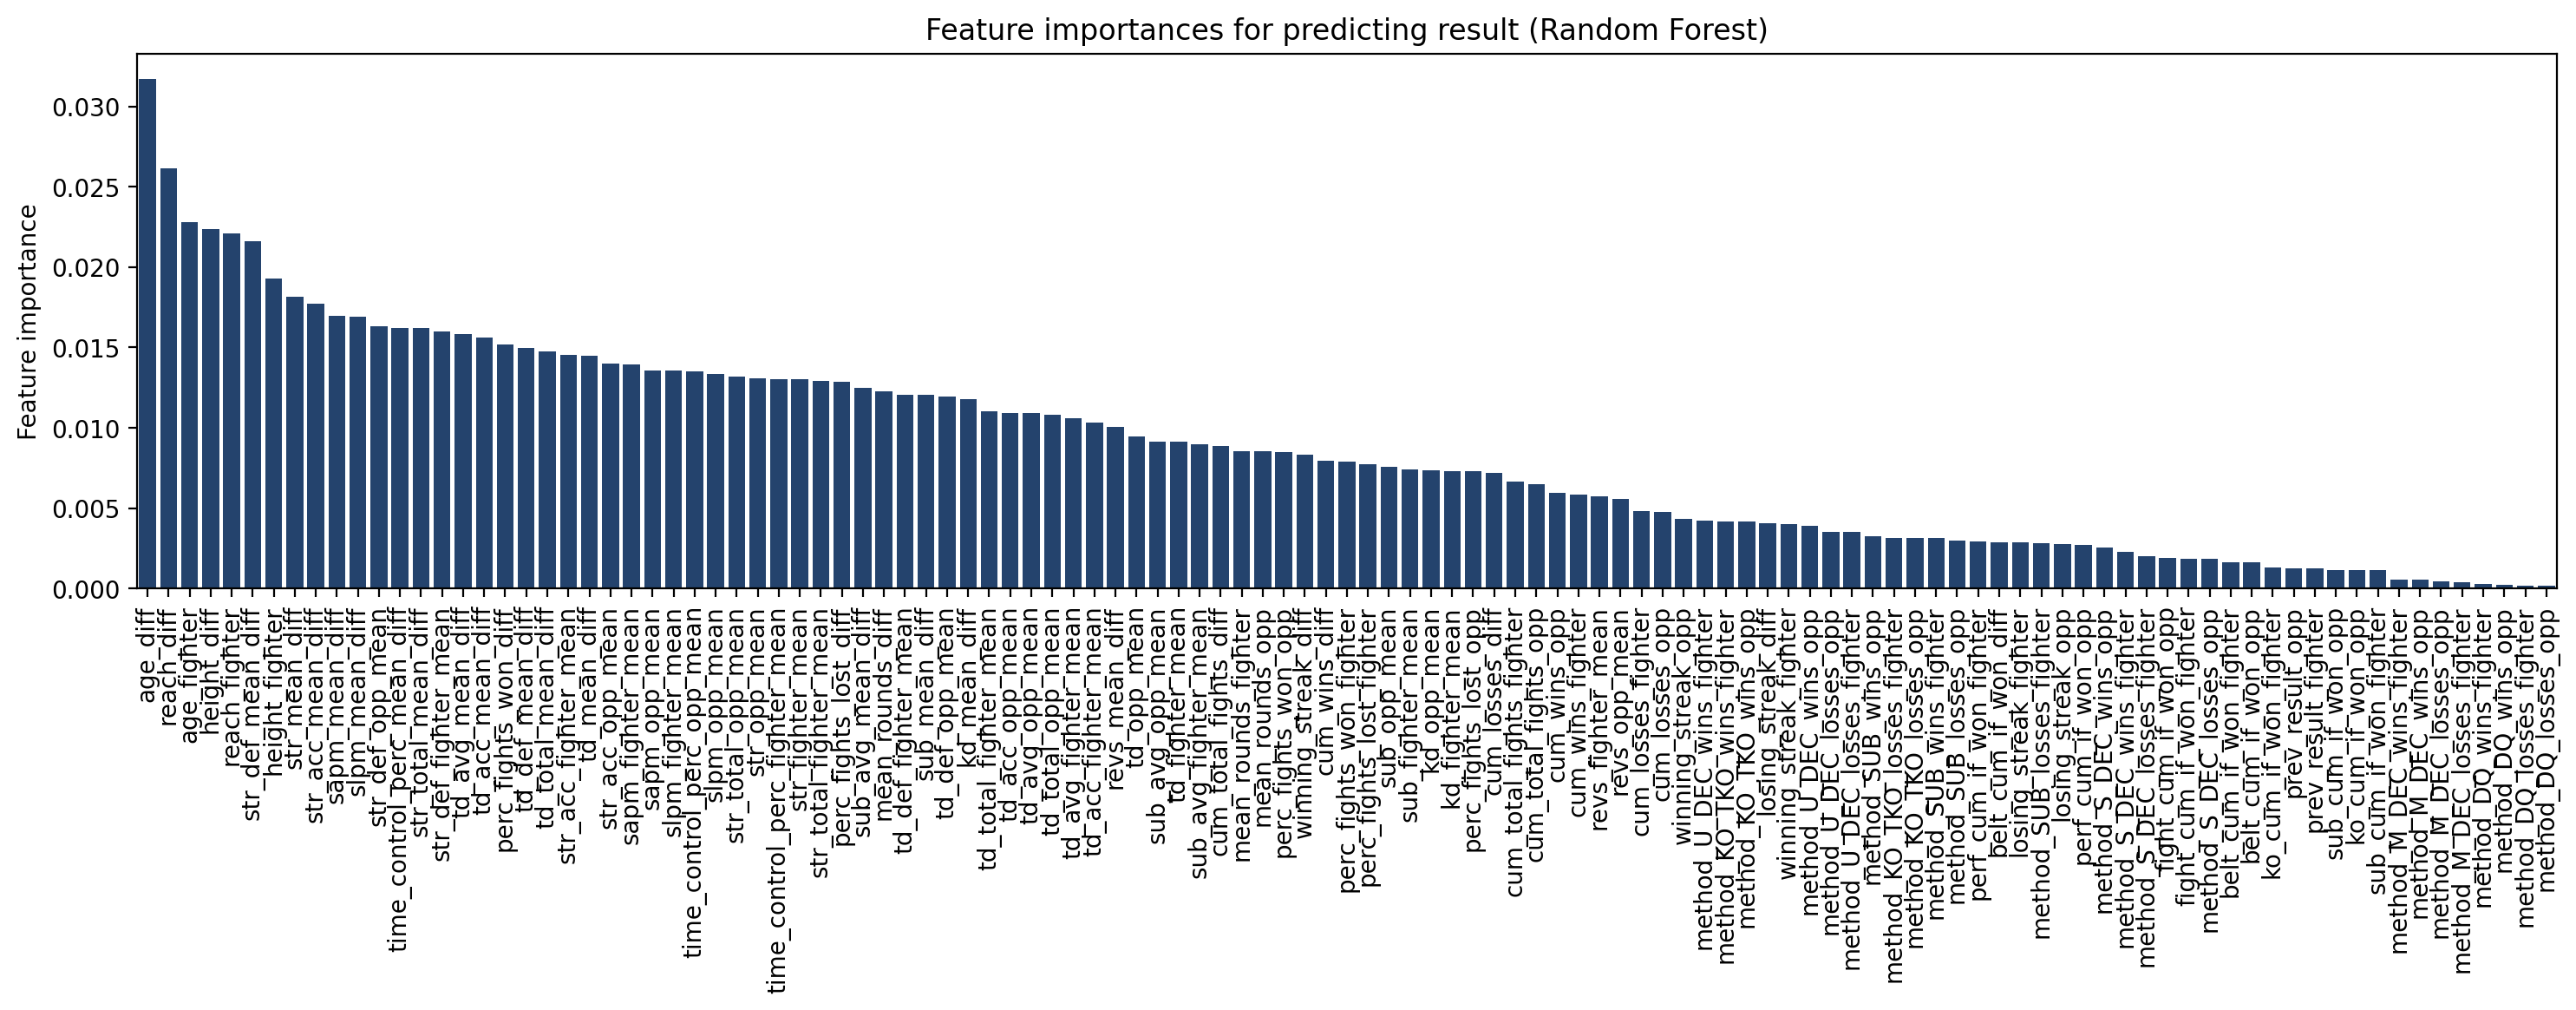

In [38]:
# plotting feature importances according to random forest

fig, axes = plt.subplots(figsize=(18, 4));
sns.barplot(pd.DataFrame({'FI': rf.feature_importances_}, index = num_cols).sort_values('FI', ascending = False)['FI']);
axes.tick_params('x', labelrotation=90)
axes.set_title('Feature importances for predicting result (Random Forest)');
axes.set_ylabel('Feature importance');